In [1]:
#Importar librerias
import matplotlib.pyplot as plt
import matplotlib.colors as colors
#import os
#import sys
import numpy as np
import networkx as nx
from networkx.algorithms.approximation import average_clustering
#import community.community_louvain as cl
import pandas as pd
#import pickle

from utils import *

In [2]:
#Importar datos
filename_e = 'celegans_connectome.csv'
df_elegans = pd.read_csv(filename_e)
df_elegans.head()

,Unnamed: 0,Neuron,Target,weight,Neurotransmitter
0,0,ADAL,AIBL,1.0,exc
1,1,ADAL,AIBR,2.0,exc
2,2,ADAL,AVAR,2.0,exc
3,3,ADAL,AVBL,4.0,exc
4,4,ADAL,AVBR,7.0,exc


In [3]:
filename_m = 'email-Eu-core.txt'
df_mails = pd.read_csv(filename_m, sep=' ', header=None)
df_mails.head()

,0,1
0,0,1
1,2,3
2,2,4
3,5,6
4,5,7


In [4]:
G_elegans = nx.from_pandas_edgelist(df_elegans, source='Neuron', target='Target', edge_attr=['weight','Neurotransmitter'], create_using=nx.DiGraph())

In [5]:
G_mails = nx.from_pandas_edgelist(df_mails, source=0, target=1, create_using=nx.Graph())

In [6]:
#Generar grafo: componente fuertemente conexa más grande, sin autoenlaces
G_e = G_elegans.copy()
G_e.remove_edges_from(nx.selfloop_edges(G_e))
largest_scc = max(nx.strongly_connected_components(G_e), key=len)
G_e = G_e.subgraph(largest_scc).copy()

In [8]:
G_m = G_mails.copy()
G_m.remove_edges_from(nx.selfloop_edges(G_m))
largest_cc = max(nx.connected_components(G_m), key=len)
G_m = G_m.subgraph(largest_cc).copy()

In [52]:
def edge_removal_fixed(G, centrality_dict=None, strategy='targeted'):

    G = G.copy()
    N = len(G)
    sizes = []

    if strategy == 'targeted':
        nodes = sorted(
            centrality_dict,
            key=centrality_dict.get,
            reverse=True
        )

    elif strategy == 'random':
        nodes = list(G.nodes())
        np.random.shuffle(nodes)

    for node in nodes:

        if G.number_of_nodes() > 0:

            if G.is_directed():
                components = nx.strongly_connected_components(G)
            else:
                components = nx.connected_components(G)

            largest_cc = max(components, key=len, default=[])

            sizes.append(len(largest_cc) / N)

            if G.has_node(node):

                if G.is_directed():
                    edges_to_remove = (
                        list(G.in_edges(node)) +
                        list(G.out_edges(node))
                    )
                else:
                    edges_to_remove = list(G.edges(node))

                G.remove_edges_from(edges_to_remove)

        else:
            sizes.append(0)

    return sizes

In [53]:
def average_random(G, centrality_dict, n_iter=100):
    curves = [edge_removal_fixed(G, centrality_dict, 'random') for _ in range(n_iter)]
    return np.mean(curves, axis=0)

In [58]:
# calcular centralidades
b_centrality_e = nx.betweenness_centrality(G_e)
d_centrality_e = nx.degree_centrality(G_e)
#o_centrality = dict(G.out_degree())
#i_centrality = dict(G.in_degree())
#p_centrality = nx.pagerank(G)
#c_centrality = nx.closeness_centrality(G)
#e_centrality = nx.eigenvector_centrality(G)

centralities_e = {
    'Intermediación': b_centrality_e,
    'Grado': d_centrality_e,
    #'Grado-Out': o_centrality,
    #'Grado-In': i_centrality,
    #'PageRank': p_centrality,
    #'Cercanía': c_centrality,
    #'Autovector': e_centrality
}

In [59]:
b_centrality_m = nx.betweenness_centrality(G_m)
d_centrality_m = nx.degree_centrality(G_m)
#o_centrality = dict(G.out_degree())
#i_centrality = dict(G.in_degree())
#p_centrality = nx.pagerank(G)
#c_centrality = nx.closeness_centrality(G)
#e_centrality = nx.eigenvector_centrality(G)

centralities_m = {
    'Intermediación': b_centrality_m,
    'Grado': d_centrality_m,
    #'Grado-Out': o_centrality,
    #'Grado-In': i_centrality,
    #'PageRank': p_centrality,
    #'Cercanía': c_centrality,
    #'Autovector': e_centrality
}

In [60]:
print(centralities_e)

{'Intermediación': {'ADAL': 0.007201491702647868, 'AIBL': 0.0399633775796476, 'AIBR': 0.018609243341479557, 'AVAR': 0.14741188177316203, 'AVBL': 0.027781085613834387, 'AVBR': 0.024496493232189796, 'AVDL': 0.016160864928653252, 'AVEL': 0.02749518034620002, 'AVJR': 0.008010615392067976, 'FLPR': 0.0009114958621380206, 'RICL': 0.01605692505802295, 'RICR': 0.018339091273799808, 'RIML': 0.0100283170590159, 'RIPL': 0.005424065681993822, 'SMDVR': 0.0015643439819347127, 'ADAR': 0.008848831827412328, 'AVAL': 0.13048483682639506, 'AVJL': 0.023989674682616414, 'RIMR': 0.02574126785715085, 'RIPR': 0.0067954643203453685, 'RIVR': 0.002807840859458815, 'SMDVL': 0.009538215453553423, 'ADEL': 0.01506768300238868, 'ADER': 0.04297323530248749, 'AVL': 0.013365762158740696, 'BDUL': 0.008556034248299425, 'CEPDL': 0.008242028592828472, 'FLPL': 0.008827108748218158, 'IL1L': 0.001248525796819769, 'IL2L': 0.0025765141293069374, 'OLLL': 0.0035942834133415656, 'RIAL': 0.02674922762595118, 'RIFL': 0.005314291545856

Calculando curva para Intermediación en Elegans...
Calculando curva para Grado en Elegans...


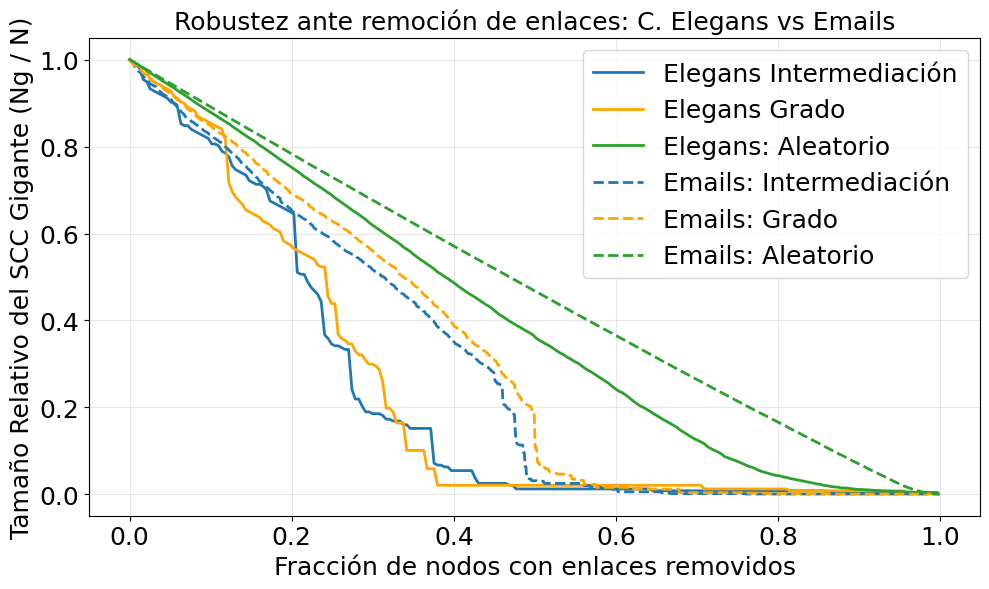

In [66]:
colors = {'Intermediación': 'tab:blue', 'Grado': 'orange', 'random': 'tab:green'}

# Escala de fuentes x4 aprox
TITLE_SIZE = 18
LABEL_SIZE =18
TICK_SIZE = 18
LEGEND_SIZE = 18

plt.figure(figsize=(10, 6))

N_e = G_e.number_of_nodes()
x_e = np.arange(N_e) / N_e

curves_e = {}
curves_m = {}

for name, centrality in centralities_e.items():
    print(f'Calculando curva para {name} en Elegans...')
    
    curves_e[f'curve_{name}'] = edge_removal_fixed(
        G_e, 
        centrality, 
        strategy='targeted'
    )
    
    plt.plot(
        x_e,
        curves_e[f'curve_{name}'],
        label=f'Elegans {name}',
        color=colors[name],
        linestyle='-',
        linewidth=2
    )

curve_random_e = average_random(G_e, centralities_e['Grado'])

plt.plot(
    x_e,
    curve_random_e,
    label='Elegans: Aleatorio',
    color=colors['random'],
    linestyle='-',
    linewidth=2
)

N_m = G_m.number_of_nodes()
x_m = np.arange(N_m) / N_m

for name, centrality in centralities_m.items():
    
    curves_m[f'curve_{name}'] = edge_removal_fixed(
        G_m,
        centrality,
        strategy='targeted'
    )
    
    plt.plot(
        x_m,
        curves_m[f'curve_{name}'],
        label=f'Emails: {name}',
        color=colors[name],
        linestyle='--',
        linewidth=2
    )

curve_random_m = average_random(G_m, centralities_m['Grado'])

plt.plot(
    x_m,
    curve_random_m,
    label='Emails: Aleatorio',
    color=colors['random'],
    linestyle='--',
    linewidth=2
)

plt.xlabel(
    'Fracción de nodos con enlaces removidos',
    fontsize=LABEL_SIZE
)

plt.ylabel(
    'Tamaño Relativo del SCC Gigante (Ng / N)',
    fontsize=LABEL_SIZE
)

plt.title(
    'Robustez ante remoción de enlaces: C. Elegans vs Emails',
    fontsize=TITLE_SIZE
)

plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)

plt.legend(fontsize=LEGEND_SIZE)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

In [67]:
for name, centrality in centralities_e.items():
    curves_e[f'curve_{name}'] = edge_removal_fixed(G_e, centrality, strategy='targeted')

for name, centrality in centralities_m.items():
    curves_m[f'curve_{name}'] = edge_removal_fixed(G_m, centrality, strategy='targeted')

In [68]:
#Cálculo de área bajo la curva para cada centralidad
areas_e = {name: np.trapezoid(curve, x_e) for name, curve in curves_e.items()}
areas_e['Aleatorio'] = np.trapezoid(curve_random_e, x_e)
areas_e

{'curve_Intermediación': np.float64(0.21983656465310045),
 'curve_Grado': np.float64(0.22553365735548078),
 'Aleatorio': np.float64(0.401329737043565)}

In [69]:
areas_m = {name: np.trapezoid(curve, x_m) for name, curve in curves_m.items()}
areas_m['Aleatorio'] = np.trapezoid(curve_random_m, x_m)
areas_m

{'curve_Intermediación': np.float64(0.2933569979716025),
 'curve_Grado': np.float64(0.3152898181025225),
 'Aleatorio': np.float64(0.4745237380116767)}

In [70]:
in_deg_e = np.array([d for _, d in G_e.in_degree()])
out_deg_e = np.array([d for _, d in G_e.out_degree()])

In [71]:
print(np.corrcoef(in_deg_e, out_deg_e)[0,1])

0.48674640547313497


In [ ]:
set_in = set([n for n, _ in top_in_e])
set_out = set([n for n, _ in top_out_e])

print("Intersección:", set_in & set_out)

In [ ]:
set_in = set([n for n, _ in top_in_m])
set_out = set([n for n, _ in top_out_m])

print("Intersección:", set_in & set_out)

In [74]:
def directional_asymmetry(G):

    asym = []

    for n in G.nodes():

        kin  = G.in_degree(n)
        kout = G.out_degree(n)

        if kin + kout > 0:

            a = abs(kin-kout)/(kin+kout)

            asym.append(a)

    return asym

In [76]:
asym_ce   = directional_asymmetry(G_e)

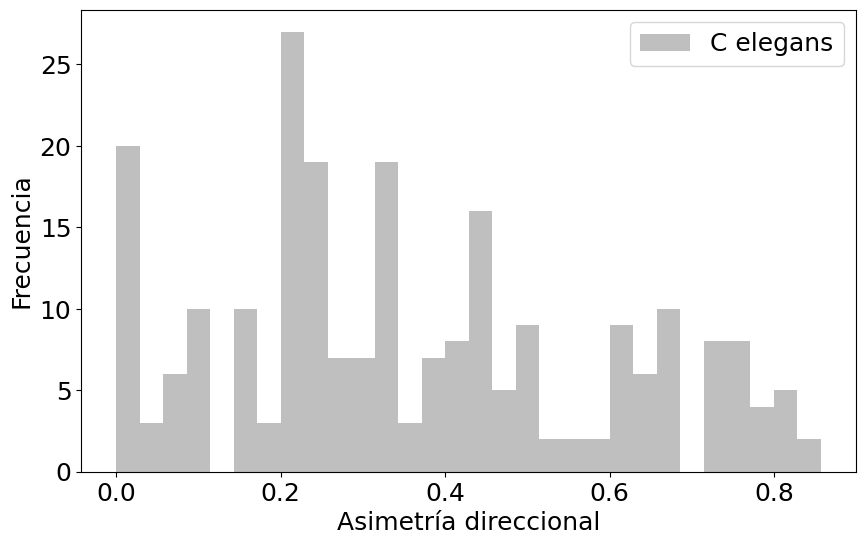

In [83]:
plt.figure(figsize=(10,6))

plt.hist(
    asym_ce,
    bins=30,
    alpha=0.5,
    label='C elegans',
    color='grey'
)

plt.xlabel('Asimetría direccional', fontsize=18)
plt.ylabel('Frecuencia', fontsize=18)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=18)

plt.show()

In [84]:
def fragment_size_distribution_normalized(G_original, ranking):

    G = G_original.copy()

    N = G.number_of_nodes()

    all_sizes = []

    for node in ranking:
        # Dentro del bucle: for node in ranking:
        if G.has_node(node):
            if G.is_directed():
                # Si es dirigido, removemos entrantes y salientes
                edges_to_remove = list(G.in_edges(node)) + list(G.out_edges(node))
            else:
                # Si no es dirigido (tu caso actual), usamos simplemente .edges()
                edges_to_remove = list(G.edges(node))
    
        G.remove_edges_from(edges_to_remove)

        sccs = sorted(
            [
                len(c)/N
                for c in nx.strongly_connected_components(G)
            ],
            reverse=True
        )

        all_sizes.append(sccs)

    return all_sizes

In [89]:
def fragment_size_distribution_normalized(G_original, ranking):
    G = G_original.copy()
    N = len(G)
    all_sizes = []
    
    # Elegimos la función de componentes según el tipo de grafo
    if G.is_directed():
        get_components = nx.strongly_connected_components
    else:
        get_components = nx.connected_components

    for node in ranking:
        if G.has_node(node):
            # 1. Manejo de aristas (ya lo habías corregido casi todo)
            if G.is_directed():
                edges_to_remove = list(G.in_edges(node)) + list(G.out_edges(node))
            else:
                edges_to_remove = list(G.edges(node))
            
            G.remove_edges_from(edges_to_remove)
            
            # 2. Manejo de componentes (aquí estaba el error actual)
            # Usamos la función que asignamos arriba (get_components)
            comps = sorted(
                [len(c) / N for c in get_components(G)],
                reverse=True
            )
            
            all_sizes.append(comps)
        else:
            # Si el nodo ya no existe, repetimos el último estado o añadimos lista vacía
            all_sizes.append(all_sizes[-1] if all_sizes else [])

    return all_sizes

In [90]:
degree_ranking_e = sorted(
    centralities_e['Grado'],
    key=centralities_e['Grado'].get,
    reverse=True
)

In [91]:
dist_e = fragment_size_distribution_normalized(
    G_e,
    degree_ranking_e
)

In [92]:
degree_ranking_m = sorted(
    centralities_m['Grado'],
    key=centralities_m['Grado'].get,
    reverse=True
)

In [93]:
dist_m = fragment_size_distribution_normalized(
    G_m,
    degree_ranking_m
)

In [94]:
def compare_fragment_rankplots(
    dist1,
    dist2,
    N1,
    N2,
    labels=('Emails','C elegans')
):

    checkpoints = [0.1,0.3,0.5,0.7]

    fig, axes = plt.subplots(
        2, 2,
        figsize=(12,8),
        sharex=False,
        sharey=False
    )

    axes = axes.flatten()

    for i, cp in enumerate(checkpoints):

        idx1 = int(cp*len(dist1))
        idx2 = int(cp*len(dist2))

        sizes1 = sorted(
            [s for s in dist1[idx1] if s > 1/N1],
            reverse=True
        )

        sizes2 = sorted(
            [s for s in dist2[idx2] if s > 1/N2],
            reverse=True
        )

        ax = axes[i]

        ax.plot(
            range(1, len(sizes1)+1),
            sizes1,
            'o-',
            alpha=0.7,
            color = 'violet',
            label=labels[0]
        )

        ax.plot(
            range(1, len(sizes2)+1),
            sizes2,
            'o-',
            alpha=0.7,
            color = 'grey',
            label=labels[1]
        )

        ax.set_title(f'{int(cp*100)}% removido')

        if i in [0,2]:
            ax.set_ylabel('Tamaño SCC normalizado')
        else:
            ax.tick_params(labelleft=True)

        if i in [2,3]:
            ax.set_xlabel('Rank SCC')
        else:
            ax.tick_params(labelbottom=True)

        #if i in [0,1]:
            #ax.set_ylim(0, 100)

        if i in [2,3]:
            #ax.set_ylim(0, 100)
            ax.set_xlabel('Rank SCC')
        ax.set_xlim(0,25)
        ax.legend()
        #ax.set_yscale('log')
    plt.tight_layout()
    #plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

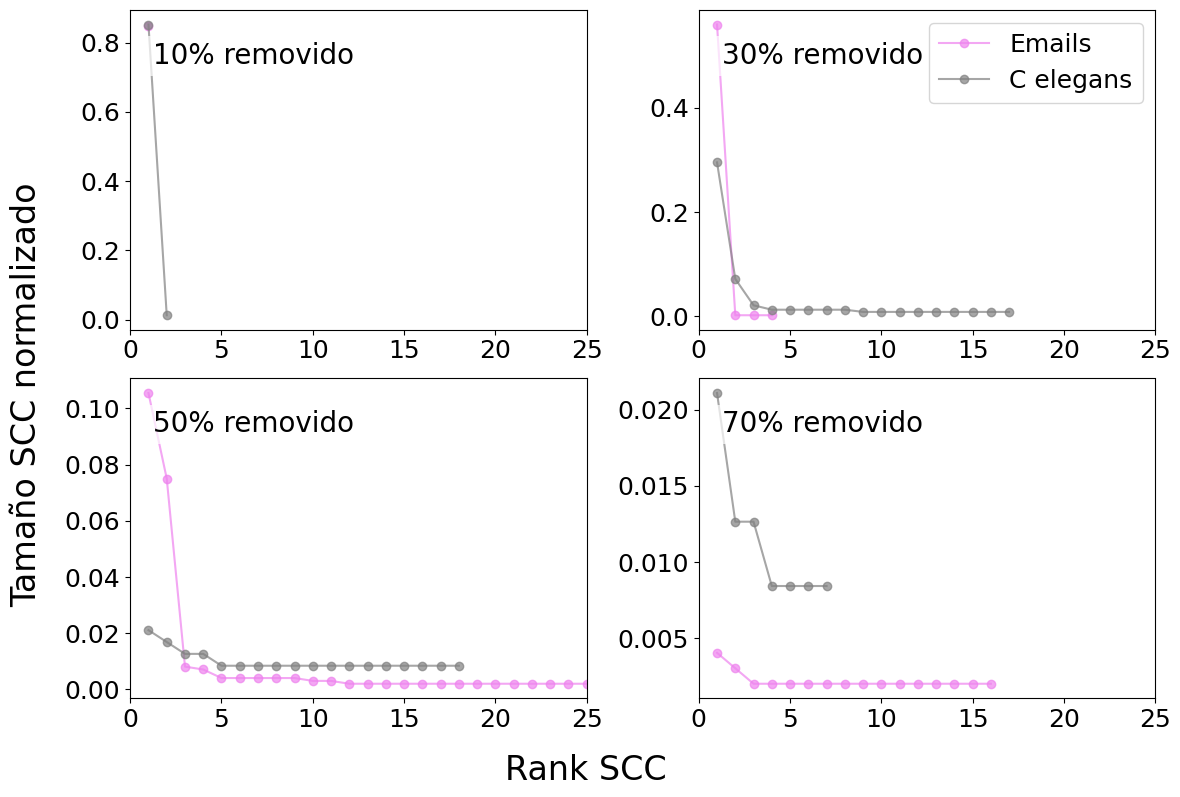

In [99]:
compare_fragment_rankplots(
    dist_m,
    dist_e,
    G_m.number_of_nodes(),
    G_e.number_of_nodes(),
    labels=('Emails','C elegans')
)

In [98]:
def compare_fragment_rankplots(
    dist1,
    dist2,
    N1,
    N2,
    labels=('Emails','C elegans')
):

    checkpoints = [0.1,0.3,0.5,0.7]

    TITLE_SIZE = 22
    LABEL_SIZE = 24
    TICK_SIZE = 18
    LEGEND_SIZE = 18
    TEXT_SIZE = 20

    fig, axes = plt.subplots(
        2, 2,
        figsize=(12,8),
        sharex=False,
        sharey=False
    )

    axes = axes.flatten()

    for i, cp in enumerate(checkpoints):

        idx1 = int(cp*len(dist1))
        idx2 = int(cp*len(dist2))

        sizes1 = sorted(
            [s for s in dist1[idx1] if s > 1/N1],
            reverse=True
        )

        sizes2 = sorted(
            [s for s in dist2[idx2] if s > 1/N2],
            reverse=True
        )

        ax = axes[i]

        ax.plot(
            range(1, len(sizes1)+1),
            sizes1,
            'o-',
            alpha=0.7,
            color='violet',
            label=labels[0]
        )

        ax.plot(
            range(1, len(sizes2)+1),
            sizes2,
            'o-',
            alpha=0.7,
            color='grey',
            label=labels[1]
        )

        # texto adentro del gráfico
        ax.text(
            0.05,
            0.90,
            f'{int(cp*100)}% removido',
            transform=ax.transAxes,
            fontsize=TEXT_SIZE,
            verticalalignment='top',
            bbox=dict(
                facecolor='white',
                alpha=0.7,
                edgecolor='none'
            )
        )

        ax.tick_params(
            axis='both',
            labelsize=TICK_SIZE
        )

        ax.set_xlim(0,25)

        # leyenda solo arriba derecha
        if i == 1:
            ax.legend(fontsize=LEGEND_SIZE)

    # labels globales
    fig.supxlabel(
        'Rank SCC',
        fontsize=LABEL_SIZE
    )

    fig.supylabel(
        'Tamaño SCC normalizado',
        fontsize=LABEL_SIZE
    )

    plt.tight_layout()

    plt.show()